In [1]:
# Import Basic Packgaes 
import numpy as np
import pandas as pd
from datetime import datetime
import statsmodels as sm
import itertools
import glob
import os
from scipy.signal import argrelextrema
from scipy.signal import find_peaks, peak_widths

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns # advanced vizs
from pandas.plotting import lag_plot


# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Set Color Palettes
palette1 = itertools.cycle(sns.color_palette(palette='Set1'))
palette2 = itertools.cycle(sns.color_palette(palette='Set2'))

In [2]:
os.chdir('D:\\TDMS')

In [3]:
os.getcwd()

'D:\\TDMS'

In [4]:
# current directory csv files
csvs = [x for x in os.listdir('D:\\TDMS') if x.endswith('.csv')]
# stats.csv -> stats
fns = [os.path.splitext(os.path.basename(x))[0] for x in csvs]

dic_csv = {}
for i in range(len(fns)):
    dic_csv[fns[i]] = pd.read_csv(csvs[i])

In [5]:
dic_csv.keys()

dict_keys(['p3_lt_2023_02_27_raw'])

In [6]:
#Set time index
for key, df in dic_csv.items():
    #df.reset_index(inplace=True)
    df['Time'] =pd.to_datetime(df['Time'])
    df.set_index(['Time'], inplace=True)

In [7]:
dic_csv['p3_lt_2023_02_27_raw'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 827474 entries, 2023-02-27 10:47:33.208000 to 2023-02-27 05:30:44.043000
Data columns (total 17 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   827474 non-null  int64  
 1   Date                         827474 non-null  object 
 2   Time(Hrs)                    827474 non-null  float64
 3   Time(Min)                    827474 non-null  float64
 4   Time(Sec)                    827474 non-null  float64
 5   P2-Cycle-Detect              827474 non-null  float64
 6   P2-CPM                       827474 non-null  float64
 7   P2_Stroke_count              827474 non-null  float64
 8   P2-Water Suction Pressure    827474 non-null  float64
 9   P2_In_diff_pressure          827474 non-null  float64
 10  P2-Water Discharge Pressure  827474 non-null  float64
 11  P2_Outlet_diff_pressure      827474 non-null  float64
 12  P2-Air-Sup

<Axes: xlabel='Time'>

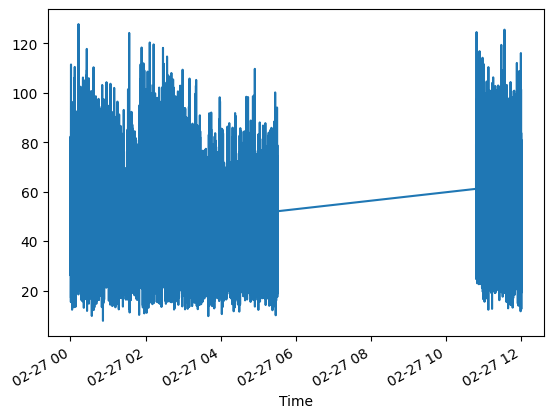

In [8]:
dic_csv['p3_lt_2023_02_27_raw']['P2-Water Discharge Pressure'].plot()

In [9]:
'''
#calculate  peak values of water discharge pressure
for i in dic_csv.values():
    # Assuming df is your DataFrame
    pressure_data = i['P1-Water Discharge Pressure']
    # Find peaks in the pressure_data
    peaks, _ = find_peaks(pressure_data)
    #insert the 
    i['Pressure_peaks'] = pressure_data[peaks]
'''

"\n#calculate  peak values of water discharge pressure\nfor i in dic_csv.values():\n    # Assuming df is your DataFrame\n    pressure_data = i['P1-Water Discharge Pressure']\n    # Find peaks in the pressure_data\n    peaks, _ = find_peaks(pressure_data)\n    #insert the \n    i['Pressure_peaks'] = pressure_data[peaks]\n"

In [10]:
#Create new dictionary to store the sliced data frame
slice_dic = {}

In [11]:
# Data frame slice range
start_time = pd.to_datetime('00:00:00.000')
end_time = pd.to_datetime('00:01:59.999')
time_interval = pd.Timedelta(minutes=1)

In [12]:
# plot sliced df
current_time = start_time
while current_time <= end_time:
    next_time = current_time + time_interval
   
    for key, df in dic_csv.items():
        # Slice the DataFrame based on the specified time range
        sliced_df = df.between_time(current_time.time(), next_time.time())
        # Store the sliced DataFrame in the new dictionary
        slice_dic[key] = sliced_df

    a = len(slice_dic)  # number of rows
    b = 1  # number of columns
    c = 1  # initialize plot counter
    fig1 = plt.figure(figsize=(60,30))

    SMALL_SIZE = 20
    
    for key, df in slice_dic.items():
        # Create a subplot and save the plot
        plt.subplot(a, b, c)
        plt.plot(df.index, df['P2-Water Discharge Pressure'])
        plt.plot(df.index, df['P2-Air-Supply-pressure'])
        plt.plot(df.index, df['P2-CPM'])
        plt.vlines(x=df.index, ymin=0, ymax=df["P2-Cycle-Detect"], linestyles='dashdot',colors='red')
        plt.ylim(0, 118)
        plt.title(key)
        c = c + 1

        plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
        plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
        plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
        plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
        plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
        # Save the plot with a filename indicating the time interval

    filename = os.path.join('D:\\TDMS', f'{key}_{current_time.strftime("%H-%M-%S")}_{next_time.strftime("%H-%M-%S")}.png')
    plt.savefig(filename)
    plt.close()
    
    current_time = next_time